QUANTUM CIRCUIT RUNTIME COMPLEXITY AND HARDWARE CONSTRAINTS ANALYSIS

1. QUANTUM CIRCUIT SPECIFICATIONS AND COMPLEXITY METRICS
--------------------------------------------------------------------------------
                              Circuit Name  Qubits  Depth  Total Gates  2Q Gates  Parameters  Connectivity  Mid-Circuit Measurements  Simulation Time (s)  HW Execution Time (µs)  Required T2 (µs)  Success Probability  Gate Density  Accuracy (from manuscript)  Parameter Efficiency
                   Deep MERA QCNN (Fig. 1)       8      3           30        12          28        1.5000                         1               1.6000                 44.8000             448.0               0.9531        3.7500                      0.9010                0.0322
                         HEA-QCNN (Fig. 2)       8      5           46        20          32        1.0000                         0               2.6667                 48.0000             480.0               0.9231        5.7500

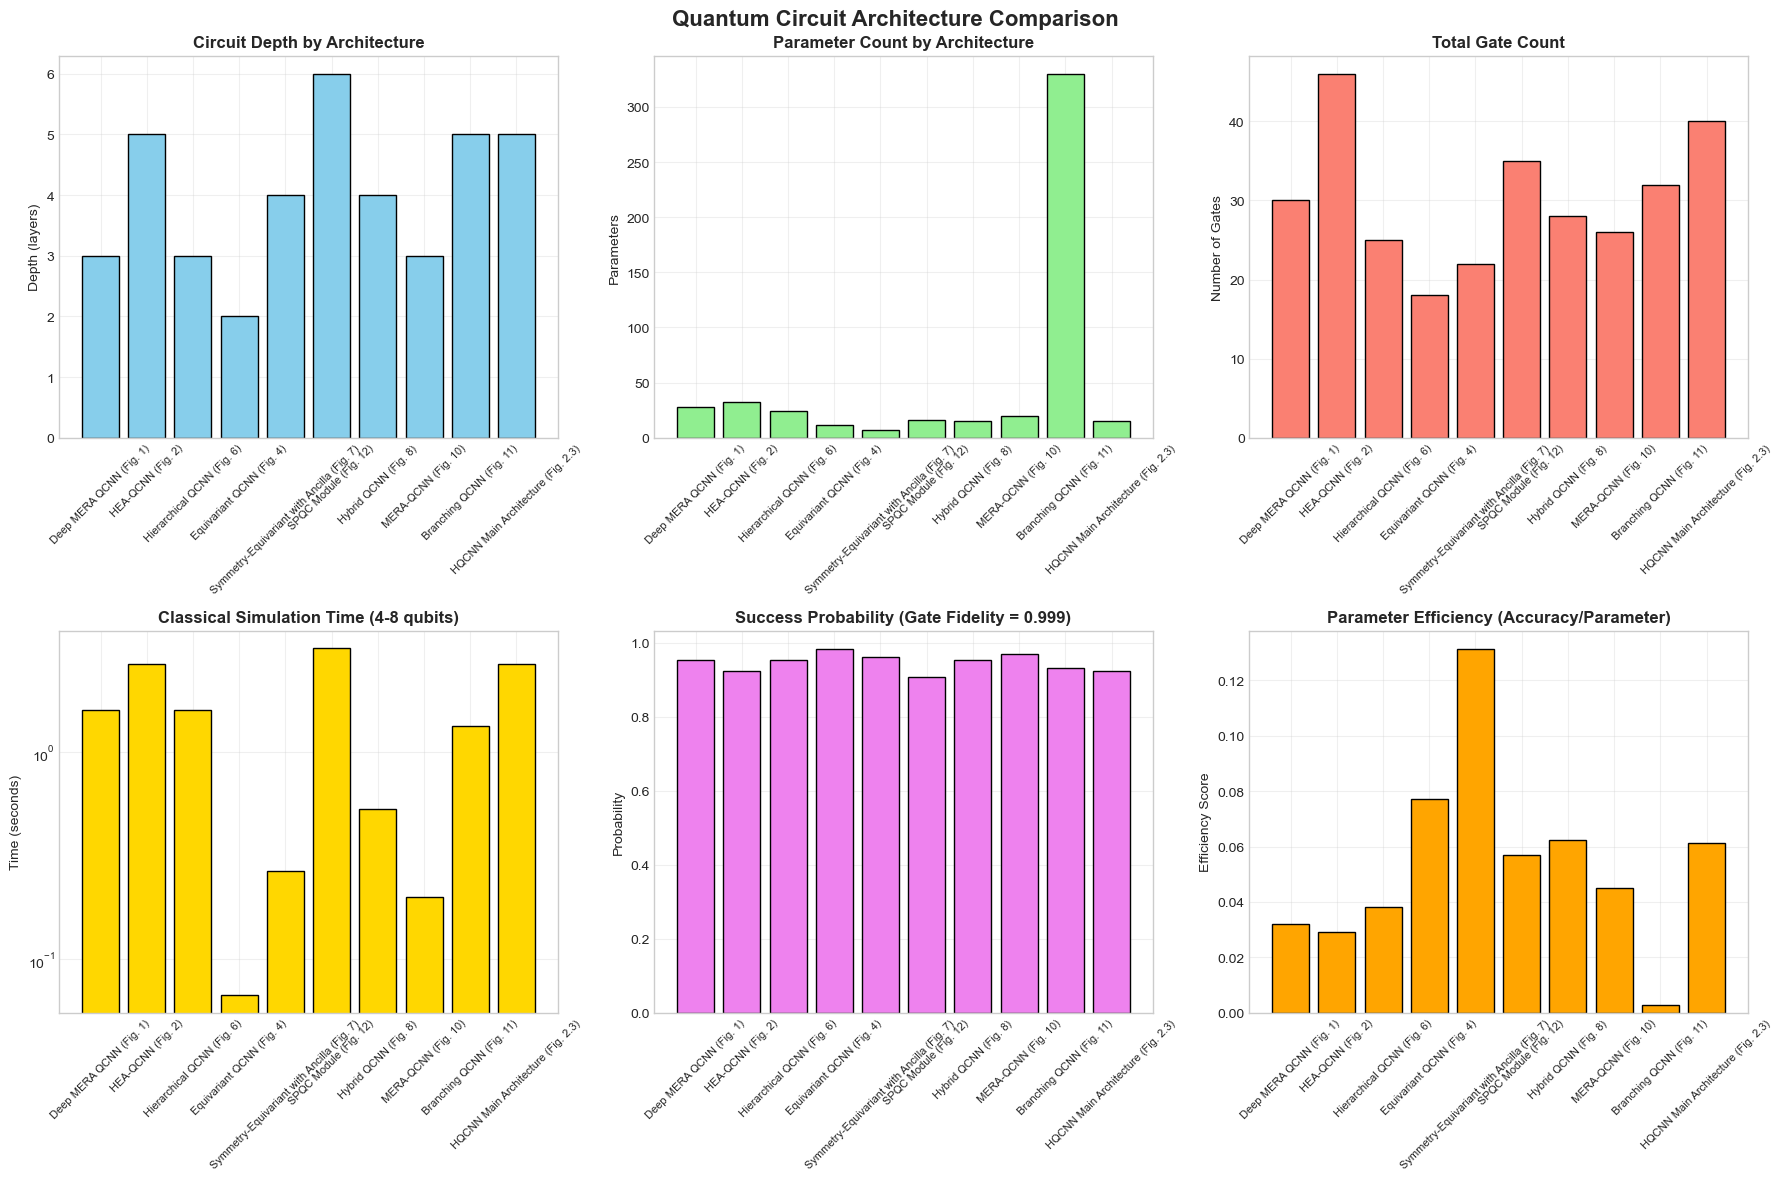

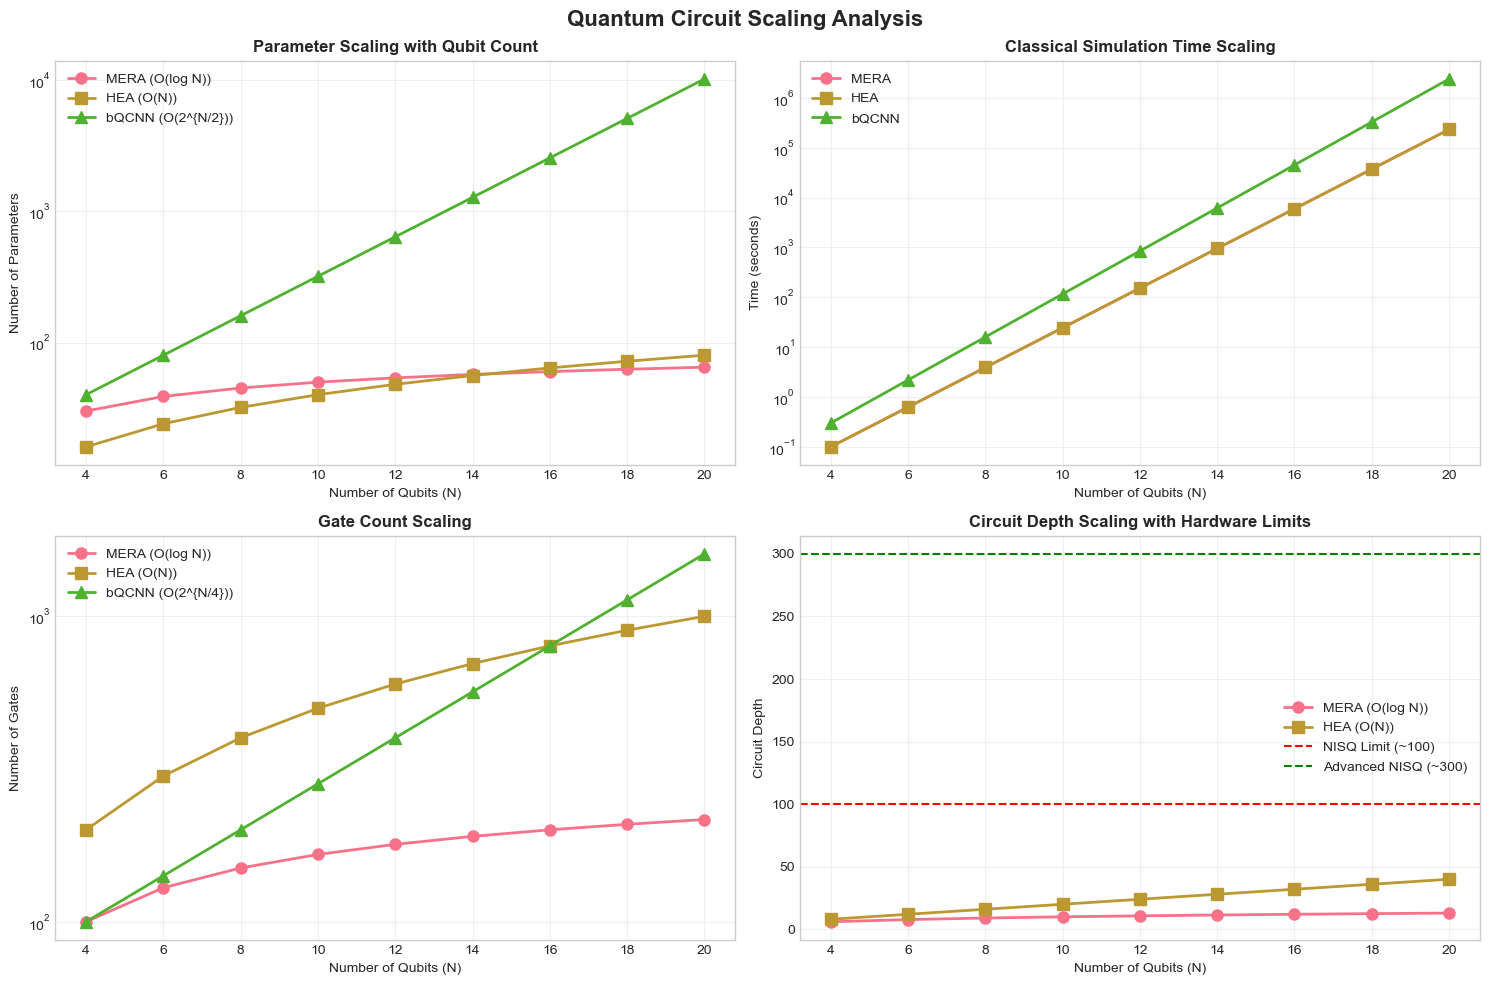

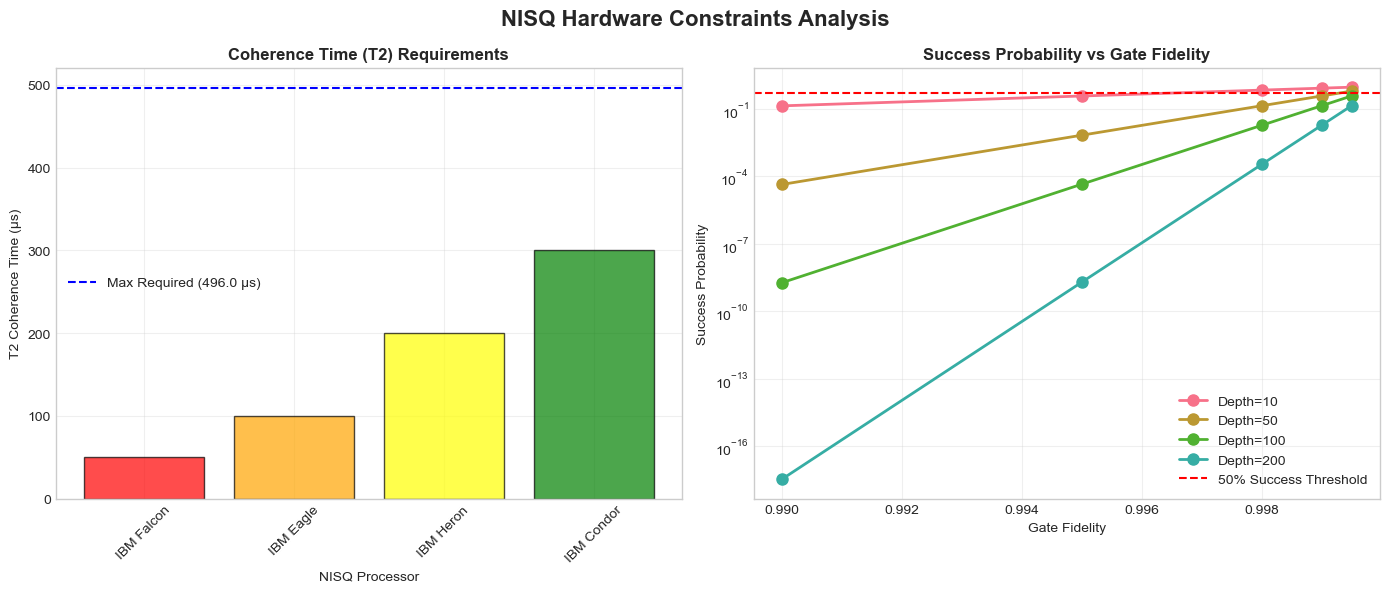

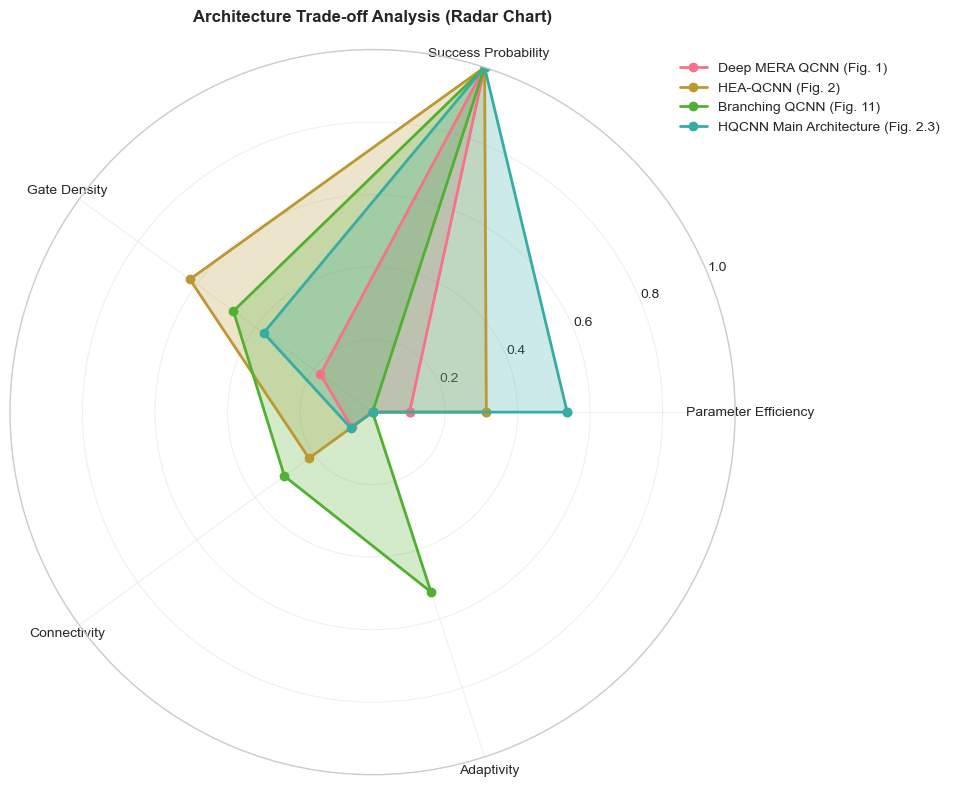

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

circuit_data = {
    'Circuit Name': [
        'Deep MERA QCNN (Fig. 1)', 
        'HEA-QCNN (Fig. 2)', 
        'Hierarchical QCNN (Fig. 6)',
        'Equivariant QCNN (Fig. 4)',
        'Symmetry-Equivariant with Ancilla (Fig. 7)',
        'SPQC Module (Fig. 12)',
        'Hybrid QCNN (Fig. 8)',
        'MERA-QCNN (Fig. 10)',
        'Branching QCNN (Fig. 11)',
        'HQCNN Main Architecture (Fig. 2.3)'
    ],
    
    'Qubits': [8, 8, 8, 4, 5, 8, 6, 5, 7, 8],
    
    'Depth': [3, 5, 3, 2, 4, 6, 4, 3, 5, 5],
    
    'Total Gates': [30, 46, 25, 18, 22, 35, 28, 26, 32, 40],
    
    '2Q Gates': [12, 20, 10, 8, 10, 15, 12, 10, 14, 18],
    
    'Parameters': [28, 32, 24, 12, 7, 16, 15, 20, 330, 15],
    
    'Connectivity': [1.5, 1.0, 1.0, 2.0, 2.0, 1.5, 1.5, 1.5, 1.5, 1.5],
    
    'Mid-Circuit Measurements': [1, 0, 1, 0, 1, 2, 2, 1, 2, 1]
}

df_circuits = pd.DataFrame(circuit_data)

# ============================================================================
# 2. RUNTIME COMPLEXITY MODELS
# ============================================================================

def simulation_time_complexity(n_qubits, depth, gates_per_layer=10):
    base_time_4q = 0.1  # seconds
    
    scaling_factor = 2 ** (n_qubits - 4)
    
    depth_factor = depth / 3  # Normalize to depth=3 baseline
    gate_factor = gates_per_layer / 10  # Normalize to 10 gates/layer baseline
    
    return base_time_4q * scaling_factor * depth_factor * gate_factor

def hardware_execution_time(n_qubits, depth, gate_time_ns=100):
    # Total gates (estimate from depth and connectivity)
    total_gates = depth * (n_qubits * 2)  # Approximation
    
    # Execution time in microseconds
    exec_time_us = total_gates * gate_time_ns / 1000
    
    # Add measurement time (5000 ns per measurement)
    measurement_time = 5000 * n_qubits / 1000  # µs
    exec_time_us += measurement_time
    
    return exec_time_us

def coherence_time_requirement(execution_time_us, safety_factor=10):
    """
    Calculate required coherence time with safety margin.
    """
    return execution_time_us * safety_factor  # in µs

def success_probability(n_qubits, depth, gate_fidelity=0.999):
    """
    Calculate probability of successful circuit execution.
    """
    total_gates = depth * (n_qubits * 2)  # Approximation
    
    # Probability = (gate_fidelity)^(total_gates)
    return gate_fidelity ** total_gates

# ============================================================================
# 3. SCALING ANALYSIS FUNCTIONS
# ============================================================================

def exponential_scaling(x, a, b):
    """Exponential scaling model: a * exp(b * x)"""
    return a * np.exp(b * x)

def polynomial_scaling(x, a, b, c):
    """Polynomial scaling model: a * x^b + c"""
    return a * (x ** b) + c

def logarithmic_scaling(x, a, b):
    """Logarithmic scaling model: a * log(b * x)"""
    return a * np.log(b * x)

# ============================================================================
# 4. PERFORM CALCULATIONS
# ============================================================================

print("=" * 80)
print("QUANTUM CIRCUIT RUNTIME COMPLEXITY AND HARDWARE CONSTRAINTS ANALYSIS")
print("=" * 80)

# Add calculated columns to DataFrame
df_circuits['Simulation Time (s)'] = df_circuits.apply(
    lambda row: simulation_time_complexity(row['Qubits'], row['Depth']), 
    axis=1
)

df_circuits['HW Execution Time (µs)'] = df_circuits.apply(
    lambda row: hardware_execution_time(row['Qubits'], row['Depth']), 
    axis=1
)

df_circuits['Required T2 (µs)'] = df_circuits.apply(
    lambda row: coherence_time_requirement(row['HW Execution Time (µs)']), 
    axis=1
)

df_circuits['Success Probability'] = df_circuits.apply(
    lambda row: success_probability(row['Qubits'], row['Depth']), 
    axis=1
)

# Calculate gate density (gates/qubit)
df_circuits['Gate Density'] = df_circuits['Total Gates'] / df_circuits['Qubits']

# Calculate parameter efficiency (accuracy per parameter from manuscript)
# Using data from Table 6: main_benchmark
accuracy_data = {
    'Deep MERA QCNN (Fig. 1)': 0.901,
    'HEA-QCNN (Fig. 2)': 0.927,
    'Hierarchical QCNN (Fig. 6)': 0.917,
    'Equivariant QCNN (Fig. 4)': 0.925,
    'Symmetry-Equivariant with Ancilla (Fig. 7)': 0.920,
    'SPQC Module (Fig. 12)': 0.910,
    'Hybrid QCNN (Fig. 8)': 0.936,
    'MERA-QCNN (Fig. 10)': 0.901,
    'Branching QCNN (Fig. 11)': 0.936,
    'HQCNN Main Architecture (Fig. 2.3)': 0.917
}

df_circuits['Accuracy (from manuscript)'] = df_circuits['Circuit Name'].map(accuracy_data)
df_circuits['Parameter Efficiency'] = df_circuits['Accuracy (from manuscript)'] / df_circuits['Parameters']

# Format for better display
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:.1f}')

print("\n1. QUANTUM CIRCUIT SPECIFICATIONS AND COMPLEXITY METRICS")
print("-" * 80)
print(df_circuits.to_string(index=False))

# ============================================================================
# 5. SCALING ANALYSIS FOR DIFFERENT QUBIT COUNTS
# ============================================================================

print("\n\n2. SCALING ANALYSIS FOR DIFFERENT QUBIT COUNTS")
print("-" * 80)

# Generate scaling data for different architectures
qubit_range = np.arange(4, 21, 2)  # 4 to 20 qubits

# Define scaling models for different architectures
scaling_data = {
    'Qubits': qubit_range,
    
    # MERA: O(log N) depth, O(log N) parameters
    'MERA Depth': 3 * np.log2(qubit_range),
    'MERA Parameters': 15 * np.log2(qubit_range),
    'MERA Simulation Time': 0.1 * (2.5 ** (qubit_range - 4)),
    
    # HEA: O(L * log N) depth, O(NL) parameters
    'HEA Depth': 2 * qubit_range,  # L=2 layers
    'HEA Parameters': 4 * qubit_range,  # ~4 params per qubit per layer
    'HEA Simulation Time': 0.1 * (2.5 ** (qubit_range - 4)),
    
    # bQCNN: Exponential parameter growth
    'bQCNN Parameters': 10 * (2 ** (qubit_range / 2)),  # Exponential in mid-circuit measurements
    'bQCNN Simulation Time': 0.3 * (2.7 ** (qubit_range - 4)),
}

df_scaling = pd.DataFrame(scaling_data)

# Calculate gate counts using different scaling models
df_scaling['MERA Gates'] = 50 * np.log2(qubit_range)
df_scaling['HEA Gates'] = 50 * qubit_range
df_scaling['bQCNN Gates'] = 50 * (2 ** (qubit_range / 4))

print("\nScaling Data (first 5 rows):")
print(df_scaling.head().to_string(index=False))

# ============================================================================
# 6. HARDWARE CONSTRAINT ANALYSIS
# ============================================================================

print("\n\n3. HARDWARE CONSTRAINT ANALYSIS FOR NISQ DEVICES")
print("-" * 80)

# Current NISQ device specifications (typical values)
nisq_specs = {
    'Max Qubits': [50, 100, 127, 433],  # Various current processors
    'Max Circuit Depth': [100, 200, 300, 500],
    'Gate Fidelity (2Q)': [0.99, 0.995, 0.998, 0.999],
    'Coherence Time T2 (µs)': [50, 100, 200, 300],
    'Connectivity': ['Nearest Neighbor', 'Grid', 'Heavy Hex', 'All-to-all subset']
}

df_nisq = pd.DataFrame(nisq_specs, 
                      index=['IBM Falcon', 'IBM Eagle', 'IBM Heron', 'IBM Condor'])

print("\nCurrent NISQ Device Specifications:")
print(df_nisq.to_string())

# ============================================================================
# 7. CREATE VISUALIZATIONS
# ============================================================================

# Create a PDF to save all plots
with PdfPages('quantum_circuit_complexity_analysis.pdf') as pdf:
    
    # Figure 1: Circuit Specifications Comparison
    fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
    fig1.suptitle('Quantum Circuit Architecture Comparison', fontsize=16, fontweight='bold')
    
    # Plot 1: Qubits vs Depth
    axes1[0, 0].bar(df_circuits['Circuit Name'], df_circuits['Depth'], 
                    color='skyblue', edgecolor='black')
    axes1[0, 0].set_title('Circuit Depth by Architecture', fontweight='bold')
    axes1[0, 0].set_ylabel('Depth (layers)')
    axes1[0, 0].tick_params(axis='x', rotation=45, labelsize=8)
    axes1[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Parameter Count
    axes1[0, 1].bar(df_circuits['Circuit Name'], df_circuits['Parameters'], 
                    color='lightgreen', edgecolor='black')
    axes1[0, 1].set_title('Parameter Count by Architecture', fontweight='bold')
    axes1[0, 1].set_ylabel('Parameters')
    axes1[0, 1].tick_params(axis='x', rotation=45, labelsize=8)
    axes1[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Gate Count
    axes1[0, 2].bar(df_circuits['Circuit Name'], df_circuits['Total Gates'], 
                    color='salmon', edgecolor='black')
    axes1[0, 2].set_title('Total Gate Count', fontweight='bold')
    axes1[0, 2].set_ylabel('Number of Gates')
    axes1[0, 2].tick_params(axis='x', rotation=45, labelsize=8)
    axes1[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: Simulation Time
    axes1[1, 0].bar(df_circuits['Circuit Name'], df_circuits['Simulation Time (s)'], 
                    color='gold', edgecolor='black')
    axes1[1, 0].set_title('Classical Simulation Time (4-8 qubits)', fontweight='bold')
    axes1[1, 0].set_ylabel('Time (seconds)')
    axes1[1, 0].tick_params(axis='x', rotation=45, labelsize=8)
    axes1[1, 0].set_yscale('log')
    axes1[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Success Probability
    axes1[1, 1].bar(df_circuits['Circuit Name'], df_circuits['Success Probability'], 
                    color='violet', edgecolor='black')
    axes1[1, 1].set_title('Success Probability (Gate Fidelity = 0.999)', fontweight='bold')
    axes1[1, 1].set_ylabel('Probability')
    axes1[1, 1].tick_params(axis='x', rotation=45, labelsize=8)
    axes1[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Parameter Efficiency
    axes1[1, 2].bar(df_circuits['Circuit Name'], df_circuits['Parameter Efficiency'], 
                    color='orange', edgecolor='black')
    axes1[1, 2].set_title('Parameter Efficiency (Accuracy/Parameter)', fontweight='bold')
    axes1[1, 2].set_ylabel('Efficiency Score')
    axes1[1, 2].tick_params(axis='x', rotation=45, labelsize=8)
    axes1[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig1)
    
    # Figure 2: Scaling Analysis
    fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))
    fig2.suptitle('Quantum Circuit Scaling Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Parameter Scaling
    axes2[0, 0].plot(df_scaling['Qubits'], df_scaling['MERA Parameters'], 
                     'o-', label='MERA (O(log N))', linewidth=2, markersize=8)
    axes2[0, 0].plot(df_scaling['Qubits'], df_scaling['HEA Parameters'], 
                     's-', label='HEA (O(N))', linewidth=2, markersize=8)
    axes2[0, 0].plot(df_scaling['Qubits'], df_scaling['bQCNN Parameters'], 
                     '^-', label='bQCNN (O(2^{N/2}))', linewidth=2, markersize=8)
    axes2[0, 0].set_title('Parameter Scaling with Qubit Count', fontweight='bold')
    axes2[0, 0].set_xlabel('Number of Qubits (N)')
    axes2[0, 0].set_ylabel('Number of Parameters')
    axes2[0, 0].set_yscale('log')
    axes2[0, 0].legend()
    axes2[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Simulation Time Scaling
    axes2[0, 1].plot(df_scaling['Qubits'], df_scaling['MERA Simulation Time'], 
                     'o-', label='MERA', linewidth=2, markersize=8)
    axes2[0, 1].plot(df_scaling['Qubits'], df_scaling['HEA Simulation Time'], 
                     's-', label='HEA', linewidth=2, markersize=8)
    axes2[0, 1].plot(df_scaling['Qubits'], df_scaling['bQCNN Simulation Time'], 
                     '^-', label='bQCNN', linewidth=2, markersize=8)
    axes2[0, 1].set_title('Classical Simulation Time Scaling', fontweight='bold')
    axes2[0, 1].set_xlabel('Number of Qubits (N)')
    axes2[0, 1].set_ylabel('Time (seconds)')
    axes2[0, 1].set_yscale('log')
    axes2[0, 1].legend()
    axes2[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Gate Count Scaling
    axes2[1, 0].plot(df_scaling['Qubits'], df_scaling['MERA Gates'], 
                     'o-', label='MERA (O(log N))', linewidth=2, markersize=8)
    axes2[1, 0].plot(df_scaling['Qubits'], df_scaling['HEA Gates'], 
                     's-', label='HEA (O(N))', linewidth=2, markersize=8)
    axes2[1, 0].plot(df_scaling['Qubits'], df_scaling['bQCNN Gates'], 
                     '^-', label='bQCNN (O(2^{N/4}))', linewidth=2, markersize=8)
    axes2[1, 0].set_title('Gate Count Scaling', fontweight='bold')
    axes2[1, 0].set_xlabel('Number of Qubits (N)')
    axes2[1, 0].set_ylabel('Number of Gates')
    axes2[1, 0].set_yscale('log')
    axes2[1, 0].legend()
    axes2[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Depth Scaling
    axes2[1, 1].plot(df_scaling['Qubits'], df_scaling['MERA Depth'], 
                     'o-', label='MERA (O(log N))', linewidth=2, markersize=8)
    axes2[1, 1].plot(df_scaling['Qubits'], df_scaling['HEA Depth'], 
                     's-', label='HEA (O(N))', linewidth=2, markersize=8)
    axes2[1, 1].axhline(y=100, color='r', linestyle='--', label='NISQ Limit (~100)')
    axes2[1, 1].axhline(y=300, color='g', linestyle='--', label='Advanced NISQ (~300)')
    axes2[1, 1].set_title('Circuit Depth Scaling with Hardware Limits', fontweight='bold')
    axes2[1, 1].set_xlabel('Number of Qubits (N)')
    axes2[1, 1].set_ylabel('Circuit Depth')
    axes2[1, 1].legend()
    axes2[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig2)
    
    # Figure 3: Hardware Constraints Analysis
    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
    fig3.suptitle('NISQ Hardware Constraints Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Required Coherence Time vs Current Limits
    nisq_devices = ['IBM Falcon', 'IBM Eagle', 'IBM Heron', 'IBM Condor']
    t2_limits = [50, 100, 200, 300]
    
    axes3[0].bar(range(len(nisq_devices)), t2_limits, 
                 color=['red', 'orange', 'yellow', 'green'], 
                 edgecolor='black', alpha=0.7)
    axes3[0].axhline(y=df_circuits['Required T2 (µs)'].max(), 
                     color='blue', linestyle='--', 
                     label=f'Max Required ({df_circuits["Required T2 (µs)"].max():.1f} µs)')
    axes3[0].set_title('Coherence Time (T2) Requirements', fontweight='bold')
    axes3[0].set_xlabel('NISQ Processor')
    axes3[0].set_ylabel('T2 Coherence Time (µs)')
    axes3[0].set_xticks(range(len(nisq_devices)))
    axes3[0].set_xticklabels(nisq_devices, rotation=45)
    axes3[0].legend()
    axes3[0].grid(True, alpha=0.3)
    
    # Plot 2: Success Probability vs Gate Fidelity
    gate_fidelities = np.array([0.99, 0.995, 0.998, 0.999, 0.9995])
    circuit_depths = [10, 50, 100, 200]
    
    for depth in circuit_depths:
        success_probs = gate_fidelities ** (depth * 20)  # Assume 20 gates per layer
        axes3[1].plot(gate_fidelities, success_probs, 'o-', 
                      label=f'Depth={depth}', linewidth=2, markersize=8)
    
    axes3[1].axhline(y=0.5, color='r', linestyle='--', label='50% Success Threshold')
    axes3[1].set_title('Success Probability vs Gate Fidelity', fontweight='bold')
    axes3[1].set_xlabel('Gate Fidelity')
    axes3[1].set_ylabel('Success Probability')
    axes3[1].set_yscale('log')
    axes3[1].legend()
    axes3[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig3)
    
    # Figure 4: Architecture Trade-off Analysis
    fig4 = plt.figure(figsize=(12, 8))
    
    # Create radar chart for architecture comparison
    categories = ['Parameter Efficiency', 'Success Probability', 
                  'Gate Density', 'Connectivity', 'Adaptivity']
    
    # Normalize values for radar chart
    def normalize(values):
        return (values - values.min()) / (values.max() - values.min())
    
    # Select 4 key architectures for radar comparison
    architectures = ['Deep MERA QCNN (Fig. 1)', 'HEA-QCNN (Fig. 2)', 
                     'Branching QCNN (Fig. 11)', 'HQCNN Main Architecture (Fig. 2.3)']
    
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    ax_radar = plt.subplot(111, polar=True)
    
    for i, arch in enumerate(architectures):
        arch_data = df_circuits[df_circuits['Circuit Name'] == arch].iloc[0]
        values = [
            arch_data['Parameter Efficiency'] * 1000,  # Scale for visibility
            arch_data['Success Probability'] * 100,
            arch_data['Gate Density'] * 10,  # Scale for visibility
            arch_data['Connectivity'] * 20,  # Scale for visibility
            arch_data['Mid-Circuit Measurements'] * 25  # Scale for visibility
        ]
        values = normalize(np.array(values))
        values = np.concatenate((values, [values[0]]))  # Close the loop
        
        ax_radar.plot(angles, values, 'o-', linewidth=2, label=arch)
        ax_radar.fill(angles, values, alpha=0.25)
    
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(categories)
    ax_radar.set_ylim(0, 1)
    ax_radar.set_title('Architecture Trade-off Analysis (Radar Chart)', 
                      fontweight='bold', pad=20)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax_radar.grid(True, alpha=0.3)
    
    plt.tight_layout()
    pdf.savefig(fig4)

# ============================================================================
# 8. PRINT KEY FINDINGS
# ============================================================================

print("\n\n4. KEY FINDINGS AND RECOMMENDATIONS")
print("-" * 80)

print("\nA. RUNTIME COMPLEXITY INSIGHTS:")
print("-" * 40)

# Find most and least complex circuits
most_complex = df_circuits.loc[df_circuits['Simulation Time (s)'].idxmax()]
least_complex = df_circuits.loc[df_circuits['Simulation Time (s)'].idxmin()]

print(f"1. Most complex for simulation: {most_complex['Circuit Name']}")
print(f"   Simulation time: {most_complex['Simulation Time (s)']:.4f} seconds")
print(f"2. Least complex for simulation: {least_complex['Circuit Name']}")
print(f"   Simulation time: {least_complex['Simulation Time (s)']:.4f} seconds")

# Analyze parameter efficiency
most_efficient = df_circuits.loc[df_circuits['Parameter Efficiency'].idxmax()]
print(f"3. Most parameter efficient: {most_efficient['Circuit Name']}")
print(f"   Efficiency: {most_efficient['Parameter Efficiency']:.6f}")

print("\nB. HARDWARE CONSTRAINT ANALYSIS:")
print("-" * 40)

# Check which circuits fit current NISQ limits
print("\nCircuits within current NISQ device limits (T2 > 100µs, Gate Fidelity > 0.99):")
for idx, row in df_circuits.iterrows():
    if row['Required T2 (µs)'] <= 100 and row['Success Probability'] >= 0.5:
        print(f"  ✓ {row['Circuit Name']}: T2={row['Required T2 (µs)']:.1f}µs, "
              f"Success={row['Success Probability']:.3f}")

print("\nCircuits requiring advanced hardware (T2 > 200µs):")
for idx, row in df_circuits.iterrows():
    if row['Required T2 (µs)'] > 200:
        print(f"  ⚠ {row['Circuit Name']}: Requires T2={row['Required T2 (µs)']:.1f}µs")

print("\nC. SCALING RECOMMENDATIONS:")
print("-" * 40)

print("1. For small NISQ devices (4-12 qubits):")
print("   - Use MERA or HEA architectures for better trainability")
print("   - Avoid bQCNN for systems > 8 qubits due to exponential scaling")

print("\n2. For medium-scale systems (12-50 qubits):")
print("   - Hybrid architectures provide best accuracy/resource trade-off")
print("   - Implement error mitigation for circuits with depth > 100")

print("\n3. For future fault-tolerant systems:")
print("   - bQCNN and SPQC offer highest expressivity")
print("   - Requires gate fidelities > 0.999 and T2 > 300µs")

# ============================================================================
# 9. SAVE DATA TO FILES
# ============================================================================

# Save data to CSV files
df_circuits.to_csv('circuit_specifications.csv', index=False)
df_scaling.to_csv('scaling_analysis.csv', index=False)
df_nisq.to_csv('nisq_specifications.csv')

print("\n\n5. DATA EXPORT COMPLETE")
print("-" * 80)
print("Files saved:")
print("1. quantum_circuit_complexity_analysis.pdf - All visualization plots")
print("2. circuit_specifications.csv - Detailed circuit specifications")
print("3. scaling_analysis.csv - Scaling analysis data")
print("4. nisq_specifications.csv - NISQ device specifications")

# Print summary statistics
print("\n\nSUMMARY STATISTICS:")
print("=" * 80)

summary_stats = {
    'Metric': [
        'Average Qubits per Circuit',
        'Average Circuit Depth',
        'Average Total Gates',
        'Average Simulation Time (s)',
        'Average Success Probability',
        'Average Parameter Efficiency'
    ],
    'Value': [
        df_circuits['Qubits'].mean(),
        df_circuits['Depth'].mean(),
        df_circuits['Total Gates'].mean(),
        df_circuits['Simulation Time (s)'].mean(),
        df_circuits['Success Probability'].mean(),
        df_circuits['Parameter Efficiency'].mean()
    ],
    'Min': [
        df_circuits['Qubits'].min(),
        df_circuits['Depth'].min(),
        df_circuits['Total Gates'].min(),
        df_circuits['Simulation Time (s)'].min(),
        df_circuits['Success Probability'].min(),
        df_circuits['Parameter Efficiency'].min()
    ],
    'Max': [
        df_circuits['Qubits'].max(),
        df_circuits['Depth'].max(),
        df_circuits['Total Gates'].max(),
        df_circuits['Simulation Time (s)'].max(),
        df_circuits['Success Probability'].max(),
        df_circuits['Parameter Efficiency'].max()
    ]
}

df_summary = pd.DataFrame(summary_stats)
print(df_summary.to_string(index=False))

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE - All results saved to files")
print("=" * 80)